In [ ]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict, Annotated,List,Literal, Optional
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from dotenv import load_dotenv
import operator
from langchain_openai import ChatOpenAI
from langgraph.types import Send
from pydantic import BaseModel, Field
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph.message import add_messages

## SQL Tools

In [146]:
import sqlite3
from langchain.tools import tool

In [147]:
@tool
def sql_db_list_tables() -> str:
    """Input is an empty string, output is a comma-separated list of tables in the database."""
    con = sqlite3.connect("/Users/vatsal/Machine Learning/Gen AI/AIproject/loan_data.db")
    try:
        cursor = con.cursor()
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        tables = [row[0] for row in cursor.fetchall() if not row[0].startswith("sqlite_")]
        return ", ".join(tables)
    finally:
        con.close()

@tool
def sql_db_query(query: str) -> str:
    """Input to this tool is a detailed and correct SQL query, output is a result from the database.
    If the query is not correct, an error message will be returned.
    If an error is returned, rewrite the query, check the query, and try again."""
    # --- read-only guardrail: enforce BEFORE executing ---
    q = query.strip().lower()
    if not q.startswith("select"):
        return "Error: only SELECT queries are permitted."
    forbidden = ("insert", "update", "delete", "drop", "alter", "create", "replace", "truncate")
    if any(word in q.split() for word in forbidden):
        return "Error: query contains a forbidden keyword. Read-only access only."

    con = sqlite3.connect("/Users/vatsal/Machine Learning/Gen AI/AIproject/loan_data.db")
    try:
        cursor = con.cursor()
        cursor.execute(query)
        return str(cursor.fetchall())
    except Exception as e:
        return f"Error: {e}"
    finally:
        con.close()

@tool
def sql_db_query_checker(query: str) -> str:
    """Use this tool to double check if your query is correct before executing it.
    Always use this tool before executing a query with sql_db_query!"""
    trigger_prompt = """{query}
Double check the sqlite query above for common mistakes, including:
- Using NOT IN with NULL values
- Using UNION when UNION ALL should have been used
- Using BETWEEN for exclusive ranges
- Data type mismatch in predicates
- Properly quoting identifiers
- Using the correct number of arguments for functions
- Casting to the correct data type
- Using the proper columns for joins

If there are any of the above mistakes, rewrite the query. If there are no mistakes, just reproduce the original query.

Output the final SQL query only.

SQL Query: """.format(query=query)

    response = llm.invoke(trigger_prompt)
    return response.text.strip()



#### Test sql tool


In [67]:

print(sql_db_list_tables.invoke(""))

print(sql_db_query.invoke("SELECT outstanding_balance FROM loans WHERE loan_id='L001'"))

print(sql_db_query.invoke("DELETE FROM loans WHERE loan_id='L001'"))

print(sql_db_query.invoke("SELECT COUNT(*) FROM loans"))

print(sql_db_query.invoke("SELECT * FROM nonexistent_table"))

customers, loans, repayments
[(240000.0,)]
Error: only SELECT queries are permitted.
[(5,)]
Error: no such table: nonexistent_table


## Loan Caluculation Tools

In [148]:
@tool
def monthly_payment(principal: float, annual_rate: float, term_months: int) -> str:
    """Calculates the monthly repayment for a loan given principal, annual rate, and term in months.
    USE WHEN: someone asks what the monthly payment is, or would be, for a given
    loan amount, rate, and term. Requires all three inputs — get them from the
    database first if they aren't provided in the question."""

    if annual_rate > 1:
        annual_rate = annual_rate / 100

    r = annual_rate / 12
    n = term_months
    result = principal / n if r == 0 else principal * (r*(1+r)**n) / ((1+r)**n - 1)
    return str(round(result, 2))

@tool
def lump_sum_recalc(outstanding_balance: float, annual_rate: float, remaining_months: int, lump_sum: float) -> str:
    """Recalculates the monthly payment after a one-off overpayment, keeping the term fixed.
    USE WHEN: someone asks how an overpayment or lump-sum payment would change their
    monthly payment. Requires current balance, rate, and remaining term — fetch these
    from the database for the specific loan before calling."""

    new_balance = outstanding_balance - lump_sum
    if new_balance <= 0:
        return {"new_monthly_payment": 0, "note": "loan fully repaid"}
    new_payment = float(monthly_payment.invoke({
    "principal": new_balance,
    "annual_rate": annual_rate,
    "term_months": remaining_months
}))
    return str({"new_balance": new_balance, "new_monthly_payment": round(new_payment, 2)})

@tool
def dti(total_monthly_debt: float, gross_monthly_income: float) -> str:
    """Calculates debt-to-income ratio as a percentage from total monthly debt and gross monthly income.
    USE WHEN: someone asks about affordability, or whether they can take on more debt.
    Requires their income and total monthly debt payments."""

    if gross_monthly_income <= 0:
        return {"error": "income must be positive"}
    return str(round((total_monthly_debt / gross_monthly_income) * 100, 2))

## Financial Agent

In [149]:
from langchain.agents import create_agent
from langchain_groq import ChatGroq
import os


os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

finacialtools = [sql_db_query_checker, sql_db_list_tables, 
            sql_db_query, monthly_payment, 
                dti, lump_sum_recalc ]


llm = ChatGroq(model="qwen/qwen3.6-27b")

system_prompt='''
You are a financial specialist for a loan operations system.
You answer questions about customer account data and perform loan calculations.

For account data (balances, rates, terms, payment history): use the SQL tools.
Always check the schema before querying, and only use SELECT queries.

For calculations (monthly payment, overpayment impact, debt-to-income): use the
calculation tools. Never compute figures yourself — always call the tool.

For questions that need both: get the account data from SQL first, then pass those
values to the calculation tool. For example, to recalculate a payment after an
overpayment, first query the loan's balance, rate, and remaining term, then call
the lump-sum recalculation tool with those values. 
For ANY account data — balance, interest rate, term, remaining months — you MUST
query the database using the SQL tools. NEVER use numbers that appear in retrieved
documents or earlier messages, even if they look correct. The database is the only
source of truth for account figures. Query SQL first, then pass those exact values
to the calculation tool.

Do not answer questions about contract terms or policy, that is outside your scope.
Amount should be in Euros(€).

'''


Financialagent = create_agent(
    model=llm,
    tools=finacialtools,
    system_prompt=system_prompt,
)



In [150]:
result = Financialagent.invoke({"messages": [("user", "What is the balance on L001?")]})
print(result["messages"][-1].content)

The balance on loan L001 is €240,000.00.


In [ ]:
result = Financialagent.invoke({"messages": [("user",
    "If I overpay 20000 on L001, what's my new monthly payment?")]})

for m in result["messages"]:
    m.pretty_print()   

================================ Human Message =================================

If I overpay 20000 on L001, what's my new monthly payment?
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (spb6dwd6y)
 Call ID: spb6dwd6y
  Args:
================================= Tool Message =================================
Name: sql_db_list_tables

customers, loans, repayments
================================== Ai Message ==================================
Tool Calls:
  sql_db_query_checker (097x6g7v0)
 Call ID: 097x6g7v0
  Args:
    query: SELECT * FROM loans WHERE loan_id = 'L001';
================================= Tool Message =================================
Name: sql_db_query_checker

<think>
The user wants me to check a specific SQL query for common mistakes based on a provided list.

**Input Query:**
`SELECT * FROM loans WHERE loan_id = 'L001';`

**List of checks:**
1.  **Using NOT IN with NULL values:** The query uses `WHERE l

In [ ]:
result = Financialagent.invoke({"messages": [("user",
    "Am I allowed to take a payment break on L001?")]})
print(result["messages"][-1].content)

I cannot answer questions regarding contract terms or policies, such as payment breaks, as this is outside my scope. Please refer to your loan agreement or contact your loan officer for assistance with this request.


### Test caluclation tool

In [25]:
print(monthly_payment.invoke({
    "principal": 200000,
    "annual_rate": 0.04,
    "term_months": 300
}))

1055.67


In [ ]:
print(lump_sum_recalc.invoke({
    "outstanding_balance": 240000,
    "annual_rate": 0.035,   
    "remaining_months": 264,
    "lump_sum": 20000
}))

{'new_balance': 220000.0, 'new_monthly_payment': 1196.1}


In [27]:
print(dti.invoke({
    "total_monthly_debt": 1500,
    "gross_monthly_income": 5000
}))

30.0


## RAG Tool

In [36]:
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings

embeddings=HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vectorstore = Chroma(
    persist_directory="/Users/vatsal/Machine Learning/Gen AI/AIproject/chroma_db",
    embedding_function=embeddings,
)


@tool
def retrieve_doc(query: str, loan_id: str) -> str:
    """Retrieves relevant clauses from a specific customer's loan agreement.
    USE WHEN: the question is about what the CONTRACT permits, requires, or states —
    overpayment rules, penalties, early-repayment terms, payment-break eligibility,
    rate-change notice, missed-payment consequences. Requires the loan_id to filter
    to the correct customer's agreement.
    DO NOT use for account figures like current balance or interest rate — those come
    from the database, not the contract."""
    retriver = vectorstore.as_retriever(
        search_type="mmr",
        search_kwargs={"k": 3, "fetch_k": 15, "filter": {"loan_id": loan_id}}
    )
    docs = retriver.invoke(query)
    if not docs:
        return "No relevant clauses found for this loan."
    return "\n\n".join(d.page_content for d in docs)



Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8531.41it/s]


## Policy Agent

In [75]:
prompt= """You are a policy specialist for a loan operations system.
You answer questions about what a customer's loan agreement permits, requires, or states.

Use the retrieve_doc tool to find relevant clauses. It requires a loan_id to filter
to the correct customer's agreement — always pass the loan_id you were given.

Base your answer ONLY on the retrieved clauses. Cite the specific clause you relied on
(e.g. "Clause 4.1"). If the retrieved clauses don't clearly answer the question, say so
rather than guessing.

When clauses appear to conflict — for example a general clause and a special addendum —
identify which one governs, and explain why. Do not answer questions about account
figures like balances or interest rates; those are outside your scope."""

model = ChatOpenAI(model='gpt-4o-mini')

policy_agent = create_agent(
    model=model,
    tools=[retrieve_doc],
    system_prompt= prompt
    )

In [77]:
response=policy_agent.invoke({'messages' : ['user', 'For loan L003, is there a penalty for overpaying?']})
print(response['messages'][-1].content)

Yes, there is a penalty for overpaying. According to **Clause 4.1 (Overpayment Penalty Clause)**, any overpayment made by the Borrower during the fixed-rate period is subject to a mandatory financial penalty equal to 2.00% of the total overpaid amount. This penalty fee is immediately payable upon execution of the overpayment.


In [79]:
response=policy_agent.invoke({'messages' : ['user', "For loan L001, what is my current balance?"]})
print(response['messages'][-1].content)

I can't provide account figures like current balances. Please consult your account statement or reach out to customer service for that information. If you have questions about your loan agreement, feel free to ask!


In [37]:
# check: do the returned chunks' METADATA all say L003, even if content looks mixed?
retriever = vectorstore.as_retriever(
    search_type="mmr",
    search_kwargs={"k": 3, "fetch_k": 15, "filter": {"loan_id": "L003"}}
)
docs = retriever.invoke("penalty for overpayment")
for d in docs:
    print(d.metadata.get("loan_id"), "|", d.metadata.get("source"), "|", d.page_content[:60])

L003 | L003_agreement.pdf | 1.2 Outstanding Balance & Duration: The present outstanding 
L003 | L003_agreement.pdf | made by the Borrower during the fixed-rate period shall incu
L003 | L003_agreement.pdf | CLAUSE 7. MISSED PAYMENTS, DEFAULT & ARREARS ENFORCEMENT
7.1


In [38]:
print(retrieve_doc.invoke({"query": "penalty for overpayment?", "loan_id": "L003"}))
print(retrieve_doc.invoke({"query": "penalty for overpayment?", "loan_id": "L001"}))

made by the Borrower during the fixed-rate period shall incur a mandatory financial penalty equal to 2.00% of the total
overpaid amount. This penalty fee is immediately payable upon execution of the overpayment. 
CLAUSE 5. EARLY REPAYMENT CHARGES (ERC)
5.1 Early Redemption Penalty: If the Borrower redeems or terminates the Loan agreement in full prior to the expiration of
the fixed-rate period, an Early Repayment Charge equal to three (3) months' gross interest on the total remaining principal
balance shall be assessed and added to the final redemption figure. 
CLAUSE 6. PROHIBITION OF PAYMENT BREAKS
6.1 Absolute Restriction: Payment breaks, payment holidays, or temporary moratoriums of any duration ARE NOT
PERMITTED under this agreement under any circumstances. The Borrower must maintain continuous uninterrupted
monthly repayments. 
Valut Bank Europe DAC — Confidential Mortgage Document Page 1 of 2

1.2 Outstanding Balance & Duration: The present outstanding principal balance is €190,

## Supervisor Agent

In [151]:
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated,List,Literal, Optional



class OutputResponse(BaseModel):
    pass


In [152]:
class DocumentState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]
    next_agent: str
    loan_id: str
    policy_result: PolicyResult
    financial_result: FinancialResult


    # --- add when you build the corresponding node ---
    # final_answer: str | None       # add with supervisor synthesis
    # grader_verdict: str | None     # add with retrieval grader
    # needs_human: bool              # add with HITL interrupt


In [153]:
from pydantic import BaseModel, Field
from typing import Literal
## Output from Supervior Agent ( Structure for sub-agent)
class RouteDecision(BaseModel):
    next_agent: Literal["financial_agent", "policy_agent", "FINISH"] = Field(
        description="Which agent to call next, or FINISH if enough information "
        "has been gathered to answer the user's question."
    )
    loan_id: str | None = Field(
        description="The loan ID mentioned in the query, e.g. 'L001'. Null if none."
    )

In [154]:
supervisor_model= ChatOpenAI(model="gpt-4o-mini")

ROUTER_SYSTEM = """You coordinate specialist agents to answer loan queries.

On each turn, decide the next step:
- financial_agent: for account data and calculations (balances, rates, payments, overpayment impact)
- policy_agent: for contract terms (overpayment rules, penalties, payment breaks, early repayment)
- FINISH: when the conversation already contains enough information to fully answer the user's question

For a question needing both contract terms AND account data, route to each agent in turn,
then FINISH. Do not route to the same agent twice for the same information.
Extract the loan ID if mentioned."""

def supervisor_node(state: DocumentState) -> dict:
    decider = supervisor_model.with_structured_output(RouteDecision)
    decision = decider.invoke([
        SystemMessage(content=ROUTER_SYSTEM),
        *state["messages"],          # sees the full conversation incl. agent outputs
    ])

    if decision.next_agent == "FINISH":
        # synthesize final answer from accumulated results
        final = supervisor_model.invoke([
            SystemMessage(content="Synthesize a final answer for the user from the conversation above."),
            *state["messages"],
        ])
        return {"next_agent": "FINISH", "messages": [final]}

    return {"next_agent": decision.next_agent, "loan_id": decision.loan_id}

def route_next(state: DocumentState) -> str:
    if state["next_agent"] == "FINISH":
        return END
    return state["next_agent"]

In [155]:
policy_model=ChatOpenAI(model="gpt-4o-mini")
class PolicyResult(BaseModel):
    answer: str = Field(description="The answer to the policy question")
    cited_clause: str = Field(description="The specific clause relied on, e.g. 'Clause 4.1'")

def policy_node(state: DocumentState) -> dict:
    result = policy_agent.invoke({"messages": state["messages"]})
    agent_answer = result["messages"][-1].content

    structurer = policy_model.with_structured_output(PolicyResult)
    structured = structurer.invoke([
        HumanMessage(content=f"Extract the answer and cited clause from this response:\n{agent_answer}")
    ])

    return {
        "messages": result["messages"],
        "policy_result": structured,  
    }

In [156]:
financial_model=ChatOpenAI(model="gpt-4o-mini")
class FinancialResult(BaseModel):
    answer: str = Field(description="The answer to the financial question")
    value: float | None = Field(
        default=None,
        description="The key numeric result if the answer contains one "
        "(e.g. a balance or monthly payment). Null if not applicable."
    )

def financial_node(state: DocumentState) -> dict:
    result = Financialagent.invoke({"messages": state["messages"]})
    agent_answer = result["messages"][-1].content

    structurer = financial_model.with_structured_output(FinancialResult)
    structured = structurer.invoke([
        HumanMessage(content=f"Extract the answer and the key numeric value from this response:\n{agent_answer}")
    ])

    return {
        "messages": result["messages"],
        "financial_result": structured,
    }

In [157]:
graph=StateGraph(DocumentState)

graph.add_node("supervisor",supervisor_node)
graph.add_node("policy_agent",policy_node)
graph.add_node("financial_agent",financial_node)

graph.add_edge(START, "supervisor")
graph.add_conditional_edges ("supervisor", route_next , {"financial_agent":"financial_agent",
                                                            "policy_agent":"policy_agent",
                                                            END:END} )


graph.add_edge("financial_agent","supervisor")
graph.add_edge("policy_agent","supervisor")

workdone= graph.compile()


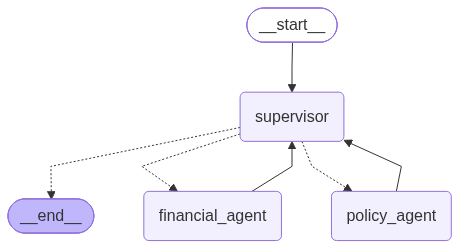

In [158]:
workdone

In [159]:
for step in workdone.stream(
    {"messages": [("user", "For L004, can I overpay 5000 without penalty, and what would my new monthly payment be?")]},
    config={"recursion_limit": 8}
):
    print(step)   # prints each node as it runs

{'supervisor': {'next_agent': 'policy_agent', 'loan_id': 'L004'}}
{'policy_agent': {'messages': [HumanMessage(content='For L004, can I overpay 5000 without penalty, and what would my new monthly payment be?', additional_kwargs={}, response_metadata={}, id='b316adde-7a77-46d5-bf62-73546f8901ad'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 306, 'total_tokens': 328, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_c400bf5046', 'id': 'chatcmpl-EB6RZFddntNvAeNfYpKn2HLiZJ8kE', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fe8ad-13ae-7d91-b504-6cb9591c0c02-0', tool_calls=[{'name': '

In [160]:
for step in workdone.stream({"messages": [("user", "What's the outstanding balance on L001?")]}):
    print(step)

{'supervisor': {'next_agent': 'financial_agent', 'loan_id': 'L001'}}
{'financial_agent': {'messages': [HumanMessage(content="What's the outstanding balance on L001?", additional_kwargs={}, response_metadata={}, id='193e3a2f-b98c-4eb4-9fad-aec9719081d9'), AIMessage(content='', additional_kwargs={'reasoning_content': 'The user is asking for the outstanding balance on a specific loan with ID "L001".\nI need to query the database to find this information.\nFirst, I should list the tables to understand the schema.\nThen, I will construct a SQL query to get the outstanding balance for loan L001.\nFinally, I will execute the query and return the result.\n\nLet\'s start by listing the tables.\n', 'tool_calls': [{'id': '9hx4nbd3a', 'function': {'arguments': '{}', 'name': 'sql_db_list_tables'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 108, 'prompt_tokens': 1162, 'total_tokens': 1270, 'completion_time': 0.210558424, 'completion_tokens_details': {'reasoning_to

In [161]:
for step in workdone.stream({"messages": [("user", "For L003, is there a penalty for overpaying?")]}):
    print(step)

{'supervisor': {'next_agent': 'policy_agent', 'loan_id': 'L003'}}
{'policy_agent': {'messages': [HumanMessage(content='For L003, is there a penalty for overpaying?', additional_kwargs={}, response_metadata={}, id='1993589e-5cb5-4621-a8fc-5b80e58ec007'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 296, 'total_tokens': 321, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_c400bf5046', 'id': 'chatcmpl-EB72o4J8PEzIplQ9aeD69PECK4YmR', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fe8d0-5227-7203-b94b-80643df51704-0', tool_calls=[{'name': 'retrieve_doc', 'args': {'query': 'penalty f

In [162]:
for step in workdone.stream({"messages": [("user", "What's the weather today?")]}):
    print(step)

{'supervisor': {'next_agent': 'FINISH', 'messages': [AIMessage(content="I'm unable to access real-time data, including current weather information. I recommend checking a reliable weather website or a weather app for the latest updates on today's weather.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 29, 'total_tokens': 61, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_25b7d0bd77', 'id': 'chatcmpl-EB735roybEPJdXxFcYOgZXPsINK1U', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fe8d0-9594-7532-a452-37861c749161-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 29, 'output_tokens': 